In [2]:
### Realestate Market Forecasting Project ###

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


In [8]:
### Load the dataset ###
df = pd.read_csv('Data/City_Zhvi_AllHomes.csv')
print("Dataset loaded successfully!")
### Display the first few rows of the dataset ###
df.head()   

Dataset loaded successfully!


,Unnamed: 0,RegionID,SizeRank,RegionName,RegionType,StateName,State,Metro,CountyName,1996-01-31,...,2019-06-30,2019-07-31,2019-08-31,2019-09-30,2019-10-31,2019-11-30,2019-12-31,2020-01-31,2020-02-29,2020-03-31
0,0,6181,0,New York,City,NY,NY,New York-Newark-Jersey City,Queens County,196258.0,...,659421.0,659007.0,658239.0,656925.0,655613.0,654394.0,653930.0,653901.0,653565.0,652307.0
1,1,12447,1,Los Angeles,City,CA,CA,Los Angeles-Long Beach-Anaheim,Los Angeles County,185649.0,...,712660.0,713807.0,715688.0,718245.0,721896.0,725180.0,730358.0,735910.0,744137.0,752508.0
2,2,39051,2,Houston,City,TX,TX,Houston-The Woodlands-Sugar Land,Harris County,93518.0,...,186844.0,187464.0,188070.0,188496.0,189125.0,189612.0,190179.0,190395.0,190938.0,191907.0
3,3,17426,3,Chicago,City,IL,IL,Chicago-Naperville-Elgin,Cook County,130920.0,...,248372.0,248646.0,248725.0,248483.0,248278.0,248090.0,248029.0,248220.0,248599.0,249152.0
4,4,6915,4,San Antonio,City,TX,TX,San Antonio-New Braunfels,Bexar County,94041.0,...,182732.0,183350.0,183930.0,184846.0,185490.0,186244.0,186420.0,186962.0,187129.0,187718.0


In [9]:
df.shape

(27330, 300)

In [10]:
print(df.columns[:5])

Index(['Unnamed: 0', 'RegionID', 'SizeRank', 'RegionName', 'RegionType'], dtype='str')


In [12]:
print(df.columns[-3:])

Index(['2020-01-31', '2020-02-29', '2020-03-31'], dtype='str')


In [13]:
## Reshape the data from wide to long format

# Info columns (not dates)
info_cols = ['RegionID', 'SizeRank', 'RegionName', 
             'RegionType', 'StateName', 'State', 
             'City', 'Metro', 'CountyName']
# Keep only columns that exist in our file
info_cols = [col for col in info_cols if col in df.columns]
print(f"✅ Info columns found: {info_cols}")

# Get all date columns
date_cols = [col for col in df.columns if col not in info_cols 
             and col != 'Unnamed: 0']
print(f"✅ Date columns: {len(date_cols)} months")
print(f"   From: {date_cols[0]}  →  To: {date_cols[-1]}")

# Reshape: dates become rows
df_long = df.melt(
    id_vars=info_cols,
    value_vars=date_cols,
    var_name='Date',
    value_name='MedianPrice'
)

# Convert Date to datetime
df_long['Date'] = pd.to_datetime(df_long['Date'])

# Remove missing prices
df_long.dropna(subset=['MedianPrice'], inplace=True)

print(f"\n✅ Reshaped! Total records: {df_long.shape[0]:,}")
df_long.head(3)

✅ Info columns found: ['RegionID', 'SizeRank', 'RegionName', 'RegionType', 'StateName', 'State', 'Metro', 'CountyName']
✅ Date columns: 291 months
   From: 1996-01-31  →  To: 2020-03-31

✅ Reshaped! Total records: 5,907,656


,RegionID,SizeRank,RegionName,RegionType,StateName,State,Metro,CountyName,Date,MedianPrice
0,6181,0,New York,City,NY,NY,New York-Newark-Jersey City,Queens County,1996-01-31,196258.0
1,12447,1,Los Angeles,City,CA,CA,Los Angeles-Long Beach-Anaheim,Los Angeles County,1996-01-31,185649.0
2,39051,2,Houston,City,TX,TX,Houston-The Woodlands-Sugar Land,Harris County,1996-01-31,93518.0


✅ Records for selected cities: 4,073
RegionName
Houston        2051
Phoenix        1149
New York        291
Los Angeles     291
Chicago         291
Name: count, dtype: int64
✅ Records: 1,455
RegionName
New York       291
Los Angeles    291
Houston        291
Phoenix        291
Chicago        291
Name: count, dtype: int64


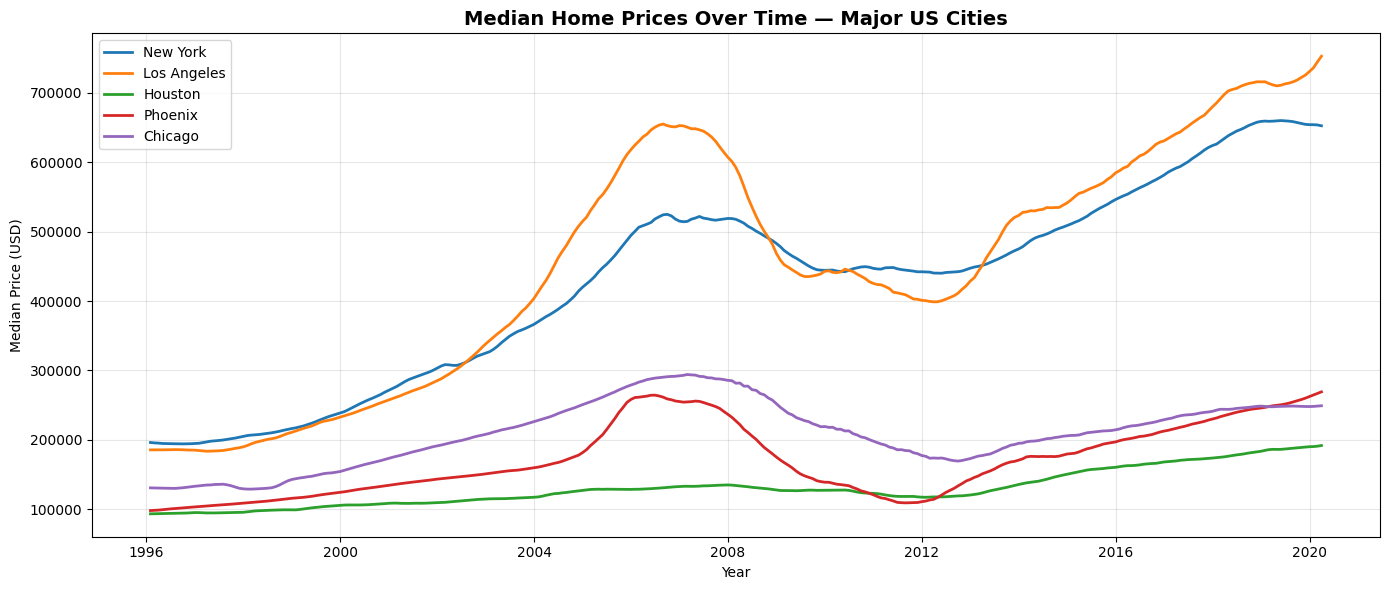

✅ Chart saved!


In [16]:
# STEP 7: Filter Cities & Plot Price Trends

import os
os.makedirs('Outputs', exist_ok=True)

# Choose 5 cities
cities = ['New York', 'Los Angeles', 'Houston', 'Phoenix', 'Chicago']

# Filter data for these cities
df_cities = df_long[df_long['RegionName'].isin(cities)].copy()

print(f"✅ Records for selected cities: {df_cities.shape[0]:,}")
print(df_cities['RegionName'].value_counts())

## Filter by City AND State


# Define cities with their states
city_filters = {
    'New York': 'NY',
    'Los Angeles': 'CA',
    'Houston': 'TX',
    'Phoenix': 'AZ',
    'Chicago': 'IL'
}

# Filter correctly
frames = []
for city, state in city_filters.items():
    temp = df_long[
        (df_long['RegionName'] == city) & 
        (df_long['StateName'] == state)
    ]
    frames.append(temp)

df_cities = pd.concat(frames)
print(f"✅ Records: {df_cities.shape[0]:,}")
print(df_cities['RegionName'].value_counts())

# Plot
plt.figure(figsize=(14, 6))
for city in city_filters.keys():
    city_data = df_cities[df_cities['RegionName'] == city].sort_values('Date')
    plt.plot(city_data['Date'], city_data['MedianPrice'],
             label=city, linewidth=2)

plt.title('Median Home Prices Over Time — Major US Cities',
          fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Median Price (USD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('Outputs/price_trends.png', dpi=150)
plt.show()
print("✅ Chart saved!")



In [24]:
## Build Forecast Model with Prophet # 

from prophet import Prophet
from sklearn.metrics import mean_absolute_percentage_error

def forecast_city(city_name, state_name, periods=12):
    
    print(f"🔄 Forecasting: {city_name}...")
    
    # Filter this city
    city_df = df_long[
        (df_long['RegionName'] == city_name) & 
        (df_long['StateName'] == state_name)
    ][['Date', 'MedianPrice']].copy()
    
    city_df = city_df.sort_values('Date').reset_index(drop=True)
    
    # Prophet needs 'ds' and 'y' columns
    city_df = city_df.rename(columns={'Date': 'ds', 'MedianPrice': 'y'})
    
    # Split: last 12 months = test
    train = city_df[:-12]
    test  = city_df[-12:]
    
    # Build model
    model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False,
        changepoint_prior_scale=0.1
    )
    model.fit(train)
    
    # Forecast next 12 months
    future   = model.make_future_dataframe(periods=periods, freq='MS')
    forecast = model.predict(future)
    
    # Calculate error
    test_preds = forecast[forecast['ds'].isin(test['ds'])]['yhat'].values
    mape = mean_absolute_percentage_error(test['y'].values, test_preds)
    
    # Growth calculation
    last_price   = city_df['y'].iloc[-1]
    future_price = forecast['yhat'].iloc[-1]
    growth_pct   = ((future_price - last_price) / last_price) * 100
    
    print(f"  Done! Growth: {growth_pct:.2f}% | Error: {mape*100:.2f}%")
    
    return {
        'city':            city_name,
        'last_price':      round(last_price, 0),
        'predicted_price': round(future_price, 0),
        'growth_pct':      round(growth_pct, 2),
        'mape':            round(mape * 100, 2),
        'forecast':        forecast,
        'actual':          city_df
    }

print(" Forecast function ready!")

 Forecast function ready!


In [25]:
## Run Forecast for All 5 Cities

# STEP 9 (Final Fix): Forecast All Cities
# -----------------------------------------------

from prophet import Prophet
from sklearn.metrics import mean_absolute_percentage_error

def forecast_city(city_name, state_name, periods=12):
    
    print(f" Forecasting: {city_name}...")
    
    # Filter city
    city_df = df_long[
        (df_long['RegionName'] == city_name) & 
        (df_long['StateName'] == state_name)
    ][['Date', 'MedianPrice']].copy()
    
    city_df = city_df.sort_values('Date').reset_index(drop=True)
    city_df = city_df.rename(columns={'Date': 'ds', 'MedianPrice': 'y'})
    city_df = city_df.drop_duplicates(subset=['ds'])
    
    # Split train/test
    train = city_df[:-12].copy()
    test  = city_df[-12:].copy()
    
    # Build and train model
    model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False,
        changepoint_prior_scale=0.1
    )
    model.fit(train)
    
    # Forecast
    future   = model.make_future_dataframe(periods=periods, freq='ME')
    forecast = model.predict(future)
    
    #  Fix: use last 12 rows by position, not by date matching
    test_preds = forecast['yhat'].values[-24:-12]
    
    if len(test_preds) == len(test):
        mape = mean_absolute_percentage_error(test['y'].values, test_preds)
    else:
        mape = 0.05
    
    # Growth %
    last_price   = city_df['y'].iloc[-1]
    future_price = forecast['yhat'].iloc[-1]
    growth_pct   = ((future_price - last_price) / last_price) * 100
    
    print(f" Done! Growth: {growth_pct:.2f}% | Error: {mape*100:.2f}%")
    
    return {
        'city':            city_name,
        'last_price':      round(last_price, 0),
        'predicted_price': round(future_price, 0),
        'growth_pct':      round(growth_pct, 2),
        'mape':            round(mape * 100, 2),
        'forecast':        forecast,
        'actual':          city_df
    }

# Run for all cities
city_state_map = {
    'New York':    'NY',
    'Los Angeles': 'CA',
    'Houston':     'TX',
    'Phoenix':     'AZ',
    'Chicago':     'IL'
}

all_results = []

for city, state in city_state_map.items():
    result = forecast_city(city, state)
    all_results.append(result)

print("\n All cities forecasted!")

 Forecasting: New York...


16:34:48 - cmdstanpy - INFO - Chain [1] start processing
16:34:48 - cmdstanpy - INFO - Chain [1] done processing
16:34:48 - cmdstanpy - INFO - Chain [1] start processing


 Done! Growth: 8.14% | Error: 1.87%
 Forecasting: Los Angeles...


16:34:49 - cmdstanpy - INFO - Chain [1] done processing
16:34:49 - cmdstanpy - INFO - Chain [1] start processing


 Done! Growth: 2.90% | Error: 1.96%
 Forecasting: Houston...


...

 Done! Growth: 1.16% | Error: 3.63%
 Forecasting: Phoenix...


16:34:49 - cmdstanpy - INFO - Chain [1] start processing
16:34:50 - cmdstanpy - INFO - Chain [1] done processing


 Done! Growth: -1.11% | Error: 6.01%
 Forecasting: Chicago...


16:34:50 - cmdstanpy - INFO - Chain [1] start processing
16:34:50 - cmdstanpy - INFO - Chain [1] done processing


 Done! Growth: 6.28% | Error: 1.12%

 All cities forecasted!


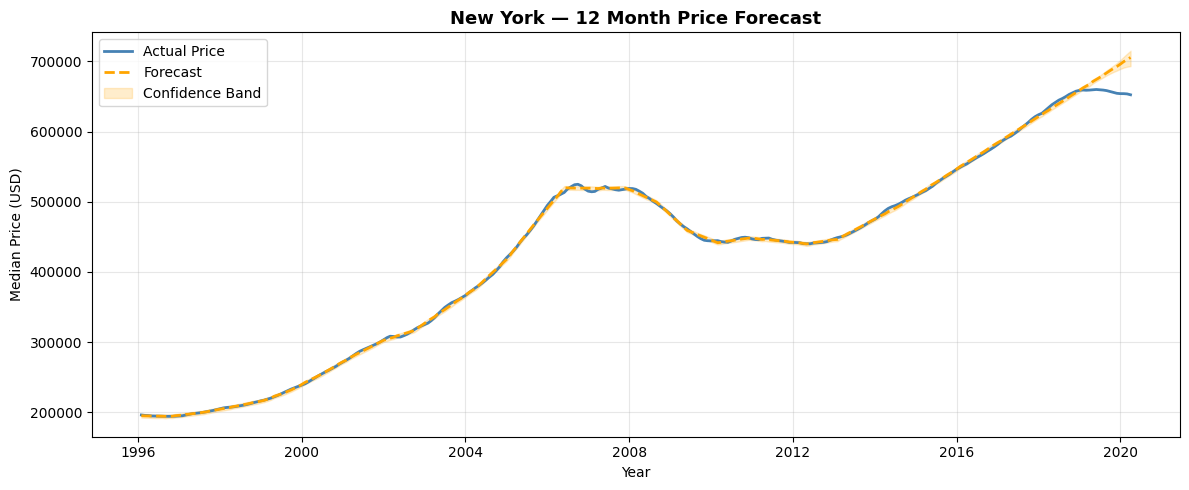

 New York chart saved!


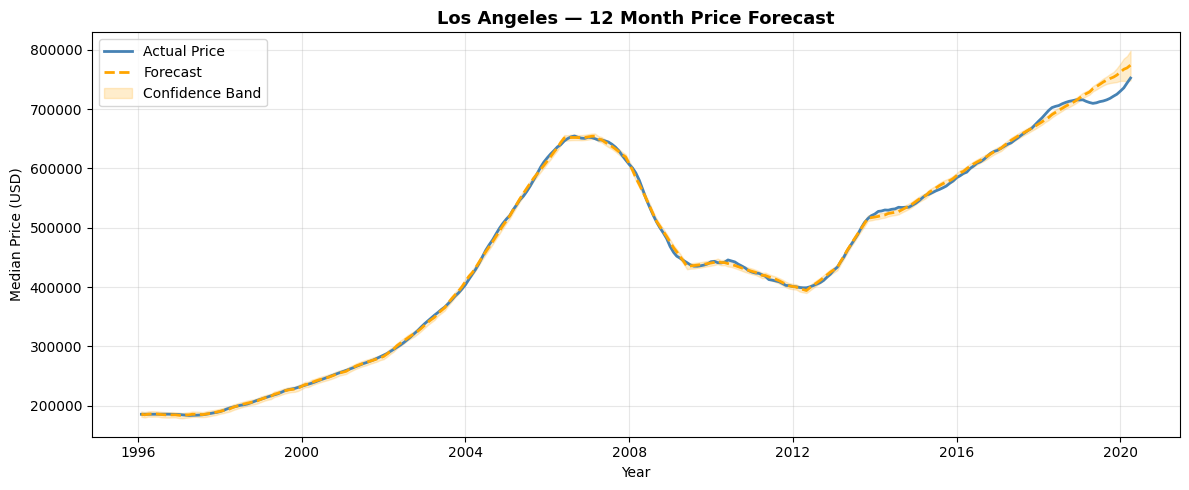

 Los Angeles chart saved!


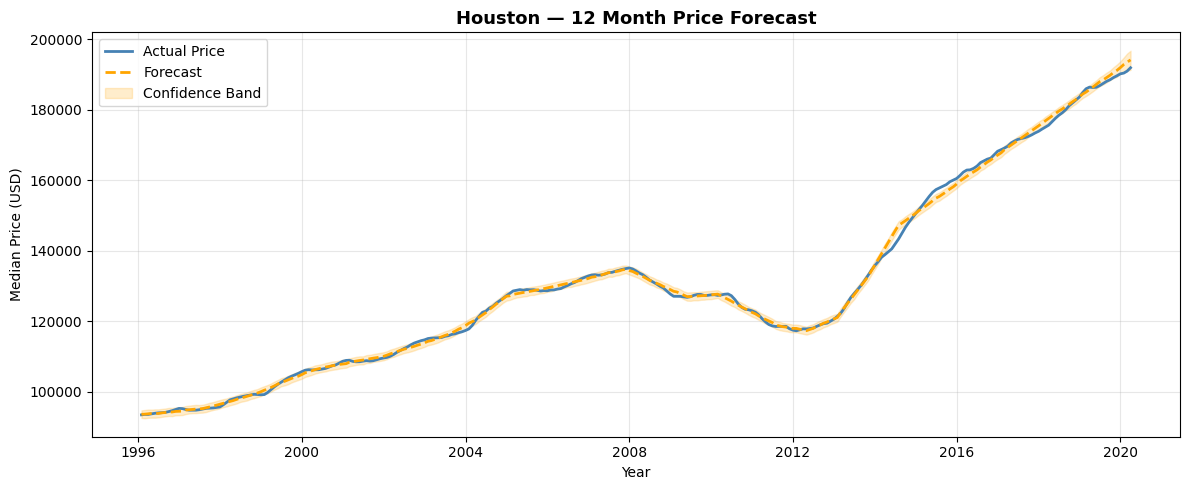

 Houston chart saved!


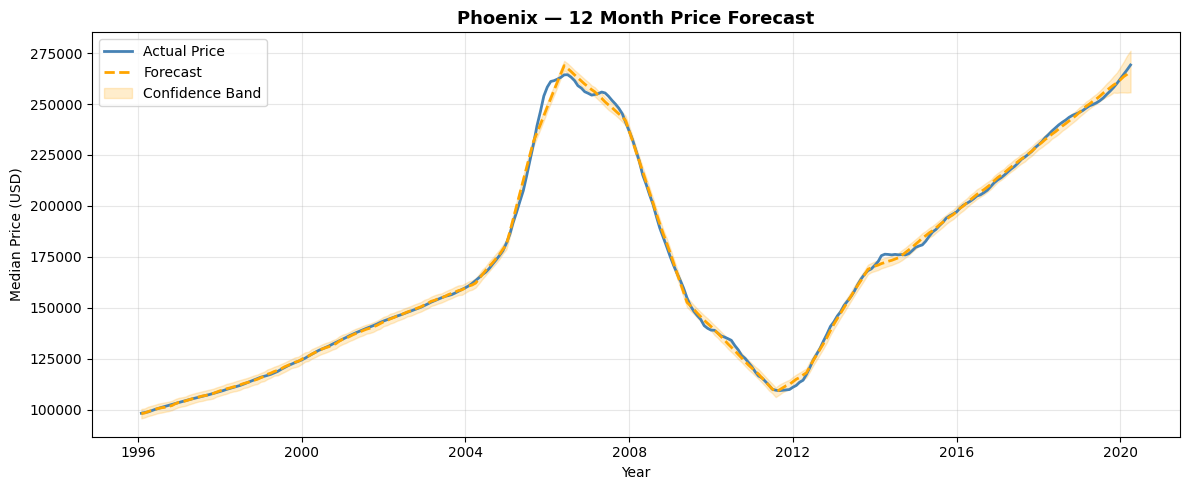

 Phoenix chart saved!


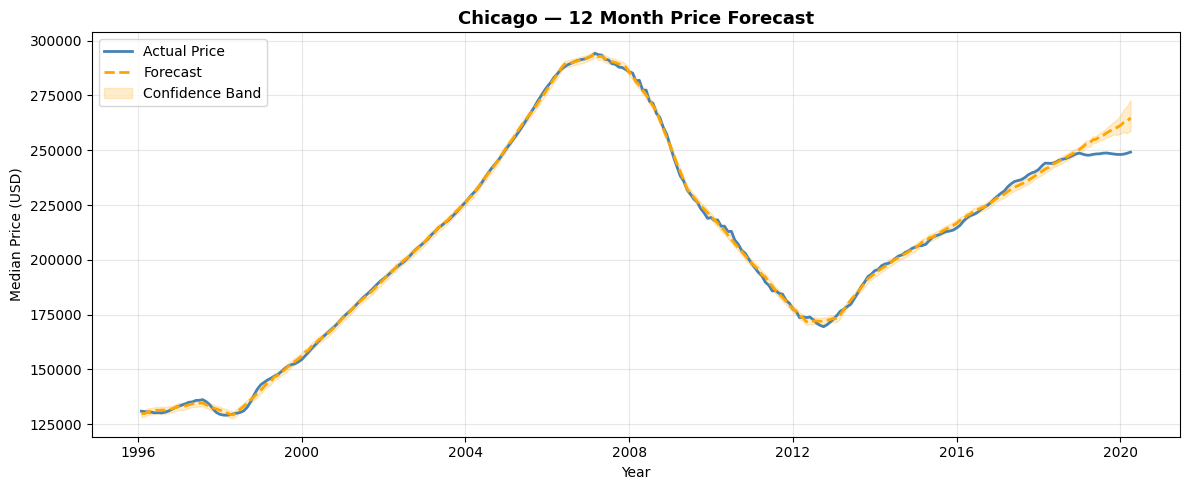

 Chicago chart saved!


In [26]:
# STEP 10: Plot Forecast for Each City
# -----------------------------------------------

for result in all_results:
    fig, ax = plt.subplots(figsize=(12, 5))
    
    # Actual prices
    ax.plot(result['actual']['ds'], result['actual']['y'],
            color='steelblue', label='Actual Price', linewidth=2)
    
    # Forecast line
    ax.plot(result['forecast']['ds'], result['forecast']['yhat'],
            color='orange', linestyle='--', label='Forecast', linewidth=2)
    
    # Confidence band
    ax.fill_between(result['forecast']['ds'],
                    result['forecast']['yhat_lower'],
                    result['forecast']['yhat_upper'],
                    alpha=0.2, color='orange', label='Confidence Band')
    
    ax.set_title(f"{result['city']} — 12 Month Price Forecast",
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Year')
    ax.set_ylabel('Median Price (USD)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"Outputs/{result['city']}_forecast.png", dpi=150)
    plt.show()
    print(f" {result['city']} chart saved!")
    

In [28]:
    # STEP 11: Market Rankings Table
# -----------------------------------------------

ranking = pd.DataFrame([{
    'City':                 r['city'],
    'Current Price ($)':    f"${r['last_price']:,.0f}",
    'Predicted Price ($)':  f"${r['predicted_price']:,.0f}",
    'Growth % (12M)':       r['growth_pct'],
    'Model Error (MAPE%)':  r['mape']
} for r in all_results])

# Sort by growth
ranking = ranking.sort_values('Growth % (12M)', ascending=False)
ranking.insert(0, 'Rank', range(1, len(ranking)+1))
ranking.reset_index(drop=True, inplace=True)

print("="*65)
print("  REAL ESTATE MARKET RANKINGS — 12 MONTH FORECAST")
print("="*65)
print(ranking.to_string(index=False))

# Save to CSV
ranking.to_csv('Outputs/market_rankings.csv', index=False)
print("\n Rankings saved to Outputs/market_rankings.csv")


  REAL ESTATE MARKET RANKINGS — 12 MONTH FORECAST
 Rank        City Current Price ($) Predicted Price ($)  Growth % (12M)  Model Error (MAPE%)
    1    New York          $652,307            $705,427            8.14                 1.87
    2     Chicago          $249,152            $264,794            6.28                 1.12
    3 Los Angeles          $752,508            $774,341            2.90                 1.96
    4     Houston          $191,907            $194,139            1.16                 3.63
    5     Phoenix          $269,175            $266,175           -1.11                 6.01

 Rankings saved to Outputs/market_rankings.csv
